# Pipeline Machine Learning: Klasifikasi Huruf EMNIST
### Menggunakan HOG Feature Extraction & SVM dengan Grid Search
---

In [ ]:
# ============================================================
# INFORMASI IDENTITAS
# ============================================================
# Nama          : Rayendra Aldo Putra
# NIM           : 4222301064
# Program Studi : Teknik Robotika
# Kelas         : Pagi C
# ============================================================

In [2]:
# ============================================================
# TAHAP 0: Import Semua Library yang Dibutuhkan
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string

from skimage.feature import hog
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

print("Semua library berhasil di-import.")

Semua library berhasil di-import.


## 1. DATA PREPARATION (Dataset: EMNIST Letters)

In [3]:
# ============================================================
# TAHAP 1A: Membaca Dataset EMNIST Letters dari File CSV
# ============================================================
# Dataset EMNIST Letters memiliki format:
# - Kolom pertama (index 0) adalah label kelas (1-26 untuk A-Z)
# - Kolom sisanya (index 1-784) adalah nilai piksel gambar 28x28

df = pd.read_csv('emnist-letters-train.csv', header=None)

print(f"Dimensi dataset asli: {df.shape}")
print(f"Jumlah total sampel : {len(df)}")
print(f"Jumlah kolom        : {df.shape[1]} (1 label + 784 piksel)")
print(f"\nDistribusi kelas (label 1-26):")
print(df[0].value_counts().sort_index())

Dimensi dataset asli: (88800, 785)
Jumlah total sampel : 88800
Jumlah kolom        : 785 (1 label + 784 piksel)

Distribusi kelas (label 1-26):
1     3396
2     3396
3     3419
4     3398
5     3437
6     3394
7     3385
8     3424
9     3428
10    3402
11    3438
12    3415
13    3402
14    3365
15    3408
16    3430
17    3435
18    3419
19    3392
20    3436
21    3419
22    3422
23    3423
24    3437
25    3453
26    3427
Name: 0, dtype: int64


In [4]:
# ============================================================
# TAHAP 1B: Sampling / Balancing Dataset
# ============================================================
# Mengambil tepat 100 sampel secara acak dari masing-masing
# 26 kelas (huruf A-Z), sehingga total = 26 x 100 = 2.600 sampel.
# Ini memastikan dataset seimbang (balanced) untuk setiap kelas.

SAMPEL_PER_KELAS = 100
RANDOM_STATE = 42

# Sampling 100 data acak per kelas menggunakan pd.concat
# (pd.concat menjaga semua kolom termasuk kolom label)
df_balanced = pd.concat([
    group.sample(n=SAMPEL_PER_KELAS, random_state=RANDOM_STATE)
    for _, group in df.groupby(df.columns[0])
]).reset_index(drop=True)

print(f"Dimensi dataset setelah balancing: {df_balanced.shape}")
print(f"Total sampel: {len(df_balanced)} (harus 2600)")
print(f"\nDistribusi kelas setelah balancing:")
print(df_balanced.iloc[:, 0].value_counts().sort_index())

Dimensi dataset setelah balancing: (2600, 785)
Total sampel: 2600 (harus 2600)

Distribusi kelas setelah balancing:
1     100
2     100
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
13    100
14    100
15    100
16    100
17    100
18    100
19    100
20    100
21    100
22    100
23    100
24    100
25    100
26    100
Name: 0, dtype: int64


In [5]:
# ============================================================
# TAHAP 1C: Memisahkan Label dan Piksel
# ============================================================
# Pisahkan kolom label (y) dan kolom piksel (X)

# Label kelas (1-26) - menggunakan iloc untuk akses posisi kolom
labels = df_balanced.iloc[:, 0].values

# Data piksel (784 kolom)
pixels = df_balanced.iloc[:, 1:].values

print(f"Shape labels: {labels.shape}")
print(f"Shape pixels: {pixels.shape}")
print(f"Rentang label: {labels.min()} - {labels.max()}")

Shape labels: (2600,)
Shape pixels: (2600, 784)
Rentang label: 1 - 26


Shape images setelah reshape & transpose: (2600, 28, 28)


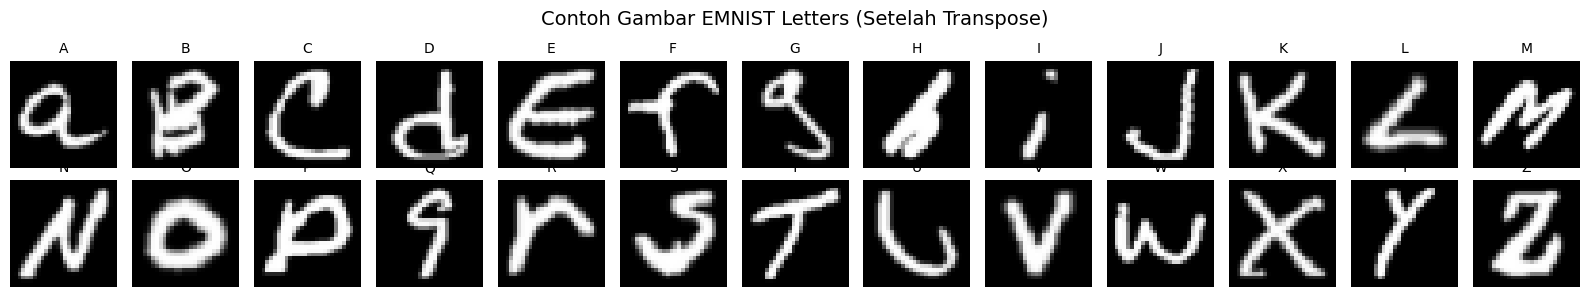

In [6]:
# ============================================================
# TAHAP 1D: Reshape dan Perbaikan Orientasi Gambar EMNIST
# ============================================================
# Gambar EMNIST memiliki orientasi bawaan yang terbalik.
# Untuk memperbaikinya, kita perlu melakukan TRANSPOSE pada
# array gambar setelah di-reshape ke 28x28.
# Langkah: reshape ke (28, 28) lalu transpose (.T)

images = []
for i in range(len(pixels)):
    # Reshape dari 784 piksel ke matriks 28x28
    img = pixels[i].reshape(28, 28)
    # Transpose untuk memperbaiki orientasi EMNIST
    img = img.T
    images.append(img)

images = np.array(images)
print(f"Shape images setelah reshape & transpose: {images.shape}")

# Visualisasi contoh gambar untuk verifikasi orientasi
fig, axes = plt.subplots(2, 13, figsize=(16, 3))
fig.suptitle('Contoh Gambar EMNIST Letters (Setelah Transpose)', fontsize=14)
for i in range(26):
    row = i // 13
    col = i % 13
    # Cari indeks sampel pertama untuk kelas i+1
    idx = np.where(labels == i + 1)[0][0]
    axes[row, col].imshow(images[idx], cmap='gray')
    axes[row, col].set_title(chr(65 + i), fontsize=10)
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

## 2. FEATURE EXTRACTION (Metode: HOG)

In [7]:
# ============================================================
# TAHAP 2: Ekstraksi Fitur HOG (Histogram of Oriented Gradients)
# ============================================================
# Parameter HOG yang digunakan (bukan default):
# - orientations  = 9     (jumlah bin orientasi gradien)
# - pixels_per_cell = (7, 7) (ukuran sel dalam piksel)
# - cells_per_block = (2, 2) (jumlah sel per blok normalisasi)
#
# Dengan gambar 28x28 dan pixels_per_cell=(7,7):
# -> Grid sel = 28/7 x 28/7 = 4x4 sel
# -> Blok = (4-1) x (4-1) = 3x3 = 9 blok
# -> Fitur per blok = 2 x 2 x 9 = 36
# -> Total fitur = 9 blok x 36 = 324 fitur per gambar

hog_features = []

for i in range(len(images)):
    # Ekstraksi fitur HOG dari setiap gambar
    fitur = hog(
        images[i],
        orientations=9,
        pixels_per_cell=(7, 7),
        cells_per_block=(2, 2)
    )
    hog_features.append(fitur)

# Konversi ke numpy array
X = np.array(hog_features)
y = labels

print(f"Shape fitur HOG (X): {X.shape}")
print(f"Jumlah fitur per gambar: {X.shape[1]}")
print(f"Shape label (y): {y.shape}")

Shape fitur HOG (X): (2600, 324)
Jumlah fitur per gambar: 324
Shape label (y): (2600,)


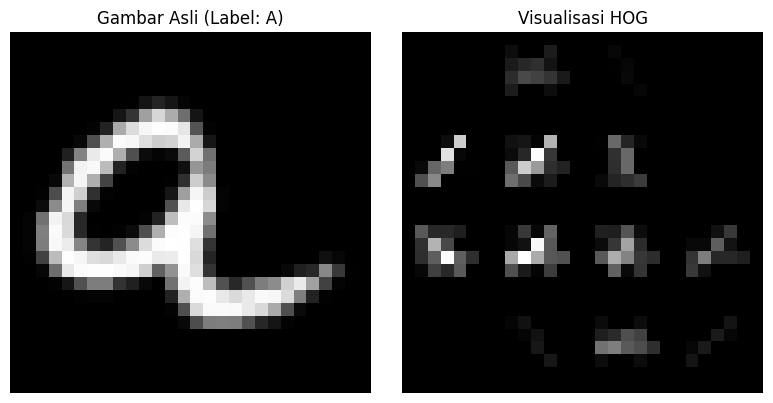

In [8]:
# Visualisasi HOG dari salah satu contoh gambar
contoh_idx = 0
fitur_contoh, hog_image = hog(
    images[contoh_idx],
    orientations=9,
    pixels_per_cell=(7, 7),
    cells_per_block=(2, 2),
    visualize=True
)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(images[contoh_idx], cmap='gray')
axes[0].set_title(f'Gambar Asli (Label: {chr(64 + labels[contoh_idx])})')
axes[0].axis('off')
axes[1].imshow(hog_image, cmap='gray')
axes[1].set_title('Visualisasi HOG')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 3. SPLIT DATASET & CLASSIFICATION (SVM + Grid Search)

In [9]:
# ============================================================
# TAHAP 3A: Membagi Dataset (Train-Test Split)
# ============================================================
# Pembagian: 80% data training, 20% data testing
# Menggunakan stratify agar proporsi kelas tetap seimbang
# di kedua subset (train dan test).

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Jumlah data training : {X_train.shape[0]} sampel")
print(f"Jumlah data testing  : {X_test.shape[0]} sampel")
print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_test : {X_test.shape}")

Jumlah data training : 2080 sampel
Jumlah data testing  : 520 sampel
Shape X_train: (2080, 324)
Shape X_test : (520, 324)


In [10]:
# ============================================================
# TAHAP 3B: Grid Search Cross-Validation untuk SVM
# ============================================================
# Mencari kombinasi hyperparameter terbaik menggunakan
# GridSearchCV dengan 5-fold cross-validation.
#
# Parameter yang di-tuning:
# - kernel: 'linear' dan 'rbf'
# - C: 0.1, 1, 10 (parameter regularisasi)
# - gamma: 'scale', 'auto' (koefisien kernel RBF)
#
# Total kombinasi: 2 kernel x 3 C x 2 gamma = 12 kombinasi
# Dengan cv=5, total fitting = 12 x 5 = 60 kali

# Definisikan model SVM dasar
svm_model = SVC()

# Definisikan ruang pencarian hyperparameter
param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

print("Memulai Grid Search... (proses ini membutuhkan waktu beberapa menit)")
print(f"Jumlah kombinasi parameter: {2 * 3 * 2} = 12")
print(f"Cross-validation folds: 5")
print(f"Total model yang dilatih: 12 x 5 = 60\n")

# Jalankan Grid Search pada data training
grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1  # Gunakan semua core CPU untuk mempercepat
)

grid_search.fit(X_train, y_train)

print(f"\n{'='*50}")
print(f"Grid Search selesai!")
print(f"{'='*50}")
print(f"Parameter terbaik   : {grid_search.best_params_}")
print(f"Akurasi CV terbaik  : {grid_search.best_score_:.4f}")

Memulai Grid Search... (proses ini membutuhkan waktu beberapa menit)
Jumlah kombinasi parameter: 12 = 12
Cross-validation folds: 5
Total model yang dilatih: 12 x 5 = 60

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Grid Search selesai!
Parameter terbaik   : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Akurasi CV terbaik  : 0.8183


## 4. EVALUATION (Metrik Performa)

In [11]:
# ============================================================
# TAHAP 4A: Prediksi Menggunakan Model Terbaik
# ============================================================
# Menggunakan estimator terbaik dari Grid Search untuk
# melakukan prediksi pada data testing.

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"Model terbaik: {best_model}")
print(f"Jumlah data testing: {len(y_test)}")
print(f"Jumlah prediksi    : {len(y_pred)}")

Model terbaik: SVC(C=10)
Jumlah data testing: 520
Jumlah prediksi    : 520


In [12]:
# ============================================================
# TAHAP 4B: Menampilkan Metrik Evaluasi
# ============================================================
# Metrik yang dihitung (menggunakan average='macro'):
# - Accuracy  : Persentase prediksi benar dari total prediksi
# - Precision : Rata-rata ketepatan prediksi positif per kelas
# - Recall    : Rata-rata sensitivitas deteksi per kelas
# - F1-Score  : Rata-rata harmonis precision dan recall per kelas

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall    = recall_score(y_test, y_pred, average='macro')
f1        = f1_score(y_test, y_pred, average='macro')

print("=" * 50)
print("       HASIL EVALUASI MODEL SVM TERBAIK")
print("=" * 50)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall    : {recall:.4f}  ({recall*100:.2f}%)")
print(f"  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)")
print("=" * 50)

# Tampilkan juga classification report lengkap per kelas
alphabet = list(string.ascii_uppercase)  # ['A', 'B', ..., 'Z']
print("\nClassification Report per kelas:")
print(classification_report(y_test, y_pred, target_names=alphabet))

       HASIL EVALUASI MODEL SVM TERBAIK
  Accuracy  : 0.8423  (84.23%)
  Precision : 0.8490  (84.90%)
  Recall    : 0.8423  (84.23%)
  F1-Score  : 0.8423  (84.23%)

Classification Report per kelas:
              precision    recall  f1-score   support

           A       0.75      0.75      0.75        20
           B       0.94      0.80      0.86        20
           C       0.77      0.85      0.81        20
           D       0.95      0.95      0.95        20
           E       0.79      0.75      0.77        20
           F       0.94      0.80      0.86        20
           G       0.75      0.60      0.67        20
           H       0.95      0.90      0.92        20
           I       0.67      0.70      0.68        20
           J       0.84      0.80      0.82        20
           K       0.90      0.90      0.90        20
           L       0.76      0.80      0.78        20
           M       0.94      0.85      0.89        20
           N       0.71      0.85      0.77  

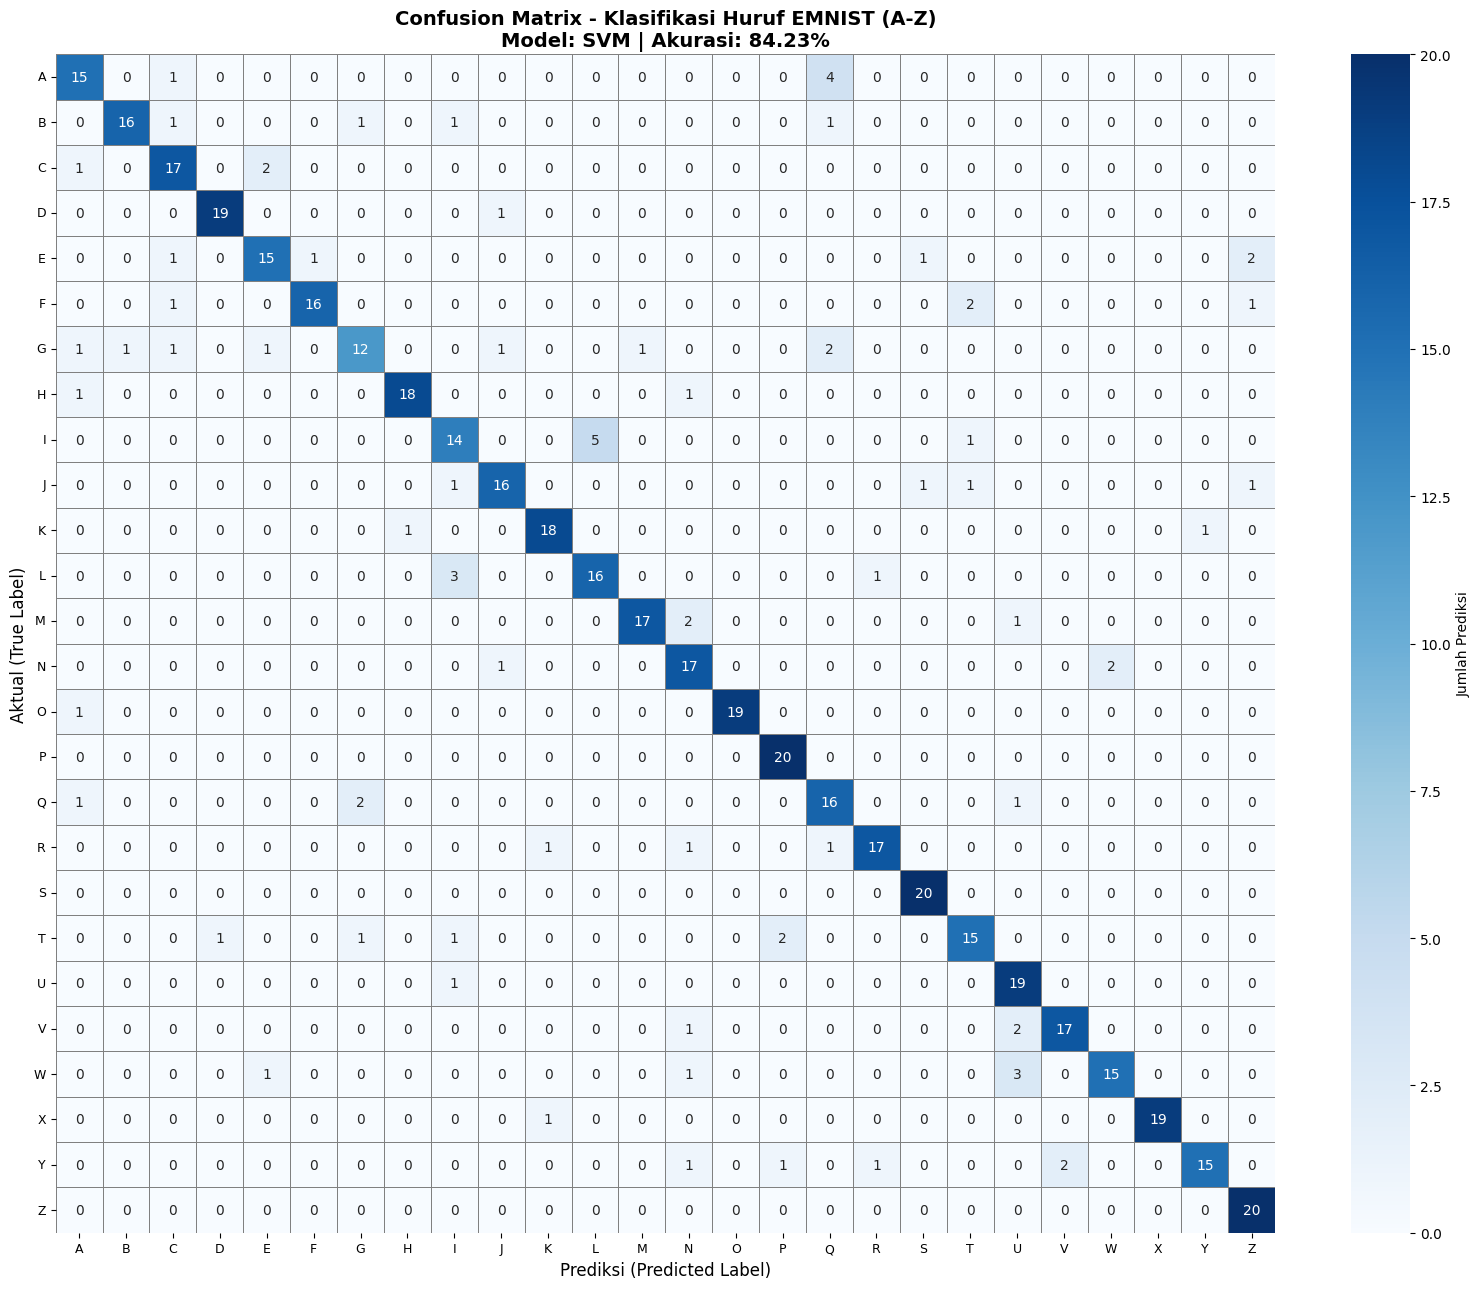


Pipeline klasifikasi huruf EMNIST selesai!


In [13]:
# ============================================================
# TAHAP 4C: Visualisasi Confusion Matrix
# ============================================================
# Membuat heatmap Confusion Matrix menggunakan Seaborn.
# Label sumbu X dan Y menggunakan huruf A-Z (bukan angka 1-26).

# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Buat daftar huruf A-Z untuk label sumbu
alphabet_labels = list(string.ascii_uppercase)

# Buat plot
plt.figure(figsize=(16, 13))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=alphabet_labels,
    yticklabels=alphabet_labels,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Jumlah Prediksi'}
)

plt.title('Confusion Matrix - Klasifikasi Huruf EMNIST (A-Z)\n'
          f'Model: SVM | Akurasi: {accuracy*100:.2f}%',
          fontsize=14, fontweight='bold')
plt.xlabel('Prediksi (Predicted Label)', fontsize=12)
plt.ylabel('Aktual (True Label)', fontsize=12)
plt.xticks(rotation=0, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print("\nPipeline klasifikasi huruf EMNIST selesai!")